# Lab 02 — Solution (Q-learning & SARSA)

Goals:
1. Implement tabular **Q-learning** (off-policy) and **SARSA** (on-policy).
2. Reuse the GridWorld and the `MABe_agent` from Lab 01.
3. Plot and compare the two agents.

Update rules:

$$ Q\text{-learning:}\quad Q(S_t, A_t) \leftarrow (1-\alpha) Q(S_t, A_t) + \alpha \big( R + \gamma \max_a Q(S_{t+1}, a) \big) $$

$$ \text{SARSA:}\quad Q(S_t, A_t) \leftarrow (1-\alpha) Q(S_t, A_t) + \alpha \big( R + \gamma Q(S_{t+1}, A_{t+1}) \big) $$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from lab01 import environment, MABe_agent

## 1.1 Q-learning agent (off-policy)

Q-learning bootstraps with $\max_a Q(S_{t+1}, a)$, which does not depend on the next action actually taken.
So the update is computed *before* selecting the next action.

In [2]:
class Q_agent(MABe_agent):
    def __init__(self, envir, init_location, epsilon=0.1, alpha=0.1, gamma=0.9):
        super().__init__(envir, init_location, epsilon)
        self.alpha = alpha
        self.gamma = gamma

    def _update_q(self, state, action, reward, next_state):
        max_next = self.Q_table[next_state].max()
        target = reward + self.gamma * max_next
        self.Q_table[state][action] = (1 - self.alpha) * self.Q_table[state][action] + self.alpha * target

    def getAction(self, observation):
        location_now, action_space, pre_reward = observation

        if location_now is not None:
            self.location_now = location_now

        if pre_reward is not None:
            self.reward_trace.append(pre_reward)
            if self.prev_state is not None and self.prev_action is not None:
                self._update_q(self.prev_state, self.prev_action, pre_reward, self.location_now)

        action = self._epsilon_greedy(self.location_now, action_space)
        self.prev_state = self.location_now
        self.prev_action = action

        assert action in action_space, 'INVALID action taken'
        return action

## 1.2 SARSA agent (on-policy)

SARSA bootstraps with $Q(S_{t+1}, A_{t+1})$, where $A_{t+1}$ is the action that the *current policy* picks at $S_{t+1}$.
So we must pick the next action *first*, then update.

In [3]:
class SARSA_agent(MABe_agent):
    def __init__(self, envir, init_location, epsilon=0.1, alpha=0.1, gamma=0.9):
        super().__init__(envir, init_location, epsilon)
        self.alpha = alpha
        self.gamma = gamma

    def _update_sarsa(self, state, action, reward, next_state, next_action):
        target = reward + self.gamma * self.Q_table[next_state][next_action]
        self.Q_table[state][action] = (1 - self.alpha) * self.Q_table[state][action] + self.alpha * target

    def getAction(self, observation):
        location_now, action_space, pre_reward = observation

        if location_now is not None:
            self.location_now = location_now

        # First choose A_{t+1} according to the current epsilon-greedy policy
        action = self._epsilon_greedy(self.location_now, action_space)

        if pre_reward is not None:
            self.reward_trace.append(pre_reward)
            if self.prev_state is not None and self.prev_action is not None:
                # On-policy update uses A_{t+1} we just picked
                self._update_sarsa(self.prev_state, self.prev_action,
                                   pre_reward, self.location_now, action)

        self.prev_state = self.location_now
        self.prev_action = action

        assert action in action_space, 'INVALID action taken'
        return action

## 1.3 Environment & simulation helper

In [4]:
def make_env():
    e = environment(8, 8)
    for s in [17, 18, 19, 21, 25, 33, 41, 42, 43, 46, 47]:
        e.map_Designate(s, 56, -15)
    e.map_Designate(15, 56, +15)
    e.map_Designate(1, 10, +5)
    e.map_Designate(26, 56, +20)
    return e

def run_simulation(agent, envir, num_iter=1000, log_freq=100,
                   init_location=0, label=''):
    data_plot = []
    chosen_action = -1
    for i in range(num_iter):
        if i == 0:
            env_observation = (init_location, envir.action_space, None)
        else:
            env_observation = envir.get_Observation(
                location=agent.location_now, action=chosen_action)
        chosen_action = agent.getAction(observation=env_observation)

        if (i + 1) % log_freq == 0:
            aver = np.mean(agent.reward_trace) if agent.reward_trace else 0.0
            data_plot.append(aver)
            print(f'{label} iter: {i + 1}\t Total reward: {agent.get_TotalReward():.2f}\t Average: {aver:.4f}')
    return data_plot

In [5]:
# Run Q-learning
np.random.seed(42)
Envir = make_env()
dummy_q_agent = Q_agent(envir=Envir, init_location=0, epsilon=0.1, alpha=0.1, gamma=0.9)
Data_plot1 = run_simulation(dummy_q_agent, Envir, num_iter=1000, log_freq=100, label='[Q    ]')

[Q    ] iter: 100	 Total reward: -145.00	 Average: -1.4646
[Q    ] iter: 200	 Total reward: -220.00	 Average: -1.1055
[Q    ] iter: 300	 Total reward: -280.00	 Average: -0.9365
[Q    ] iter: 400	 Total reward: -340.00	 Average: -0.8521
[Q    ] iter: 500	 Total reward: -370.00	 Average: -0.7415
[Q    ] iter: 600	 Total reward: -415.00	 Average: -0.6928
[Q    ] iter: 700	 Total reward: -460.00	 Average: -0.6581
[Q    ] iter: 800	 Total reward: -505.00	 Average: -0.6320
[Q    ] iter: 900	 Total reward: -520.00	 Average: -0.5784
[Q    ] iter: 1000	 Total reward: -530.00	 Average: -0.5305


In [6]:
# Run SARSA
np.random.seed(42)
Envir = make_env()
dummy_sarsa_agent = SARSA_agent(envir=Envir, init_location=0, epsilon=0.1, alpha=0.1, gamma=0.9)
Data_plot2 = run_simulation(dummy_sarsa_agent, Envir, num_iter=1000, log_freq=100, label='[SARSA]')

[SARSA] iter: 100	 Total reward: -145.00	 Average: -1.4646
[SARSA] iter: 200	 Total reward: -220.00	 Average: -1.1055
[SARSA] iter: 300	 Total reward: -295.00	 Average: -0.9866
[SARSA] iter: 400	 Total reward: -325.00	 Average: -0.8145
[SARSA] iter: 500	 Total reward: -385.00	 Average: -0.7715
[SARSA] iter: 600	 Total reward: -430.00	 Average: -0.7179
[SARSA] iter: 700	 Total reward: -445.00	 Average: -0.6366
[SARSA] iter: 800	 Total reward: -440.00	 Average: -0.5507
[SARSA] iter: 900	 Total reward: -470.00	 Average: -0.5228
[SARSA] iter: 1000	 Total reward: -500.00	 Average: -0.5005


## 1.4 Plot — compare Q-learning vs SARSA

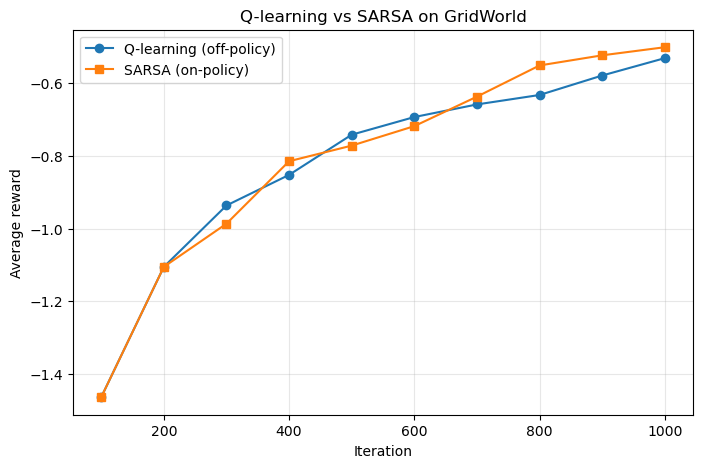

In [7]:
fig = plt.figure(figsize=(8, 5))
x = np.arange(1, len(Data_plot1) + 1) * 100
plt.plot(x, Data_plot1, marker='o', label='Q-learning (off-policy)')
plt.plot(x, Data_plot2, marker='s', label='SARSA (on-policy)')
plt.xlabel('Iteration')
plt.ylabel('Average reward')
plt.title('Q-learning vs SARSA on GridWorld')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 1.5 Inspect the learned Q-table

In [8]:
ACTION_SYMBOLS = ['^', 'v', '<', '>']

def show_policy(agent, height=8, width=8, name='policy'):
    policy = np.full((height, width), ' ', dtype='<U1')
    values = np.zeros((height, width))
    for s in range(height * width):
        r, c = divmod(s, width)
        best = int(np.argmax(agent.Q_table[s]))
        policy[r, c] = ACTION_SYMBOLS[best]
        values[r, c] = agent.Q_table[s].max()
    print(f'== {name}: greedy action per state ==')
    for row in policy:
        print(' '.join(row))
    print(f'\n== {name}: max Q per state ==')
    print(np.round(values, 2))

show_policy(dummy_q_agent, name='Q-learning')
print()
show_policy(dummy_sarsa_agent, name='SARSA')

== Q-learning: greedy action per state ==
^ < ^ ^ ^ ^ ^ ^
^ ^ ^ ^ ^ ^ ^ ^
^ ^ ^ ^ ^ ^ ^ ^
^ ^ > ^ ^ ^ ^ ^
^ v ^ ^ ^ ^ ^ ^
^ ^ ^ ^ ^ ^ > v
^ v v v ^ ^ ^ ^
^ ^ ^ ^ ^ ^ ^ ^

== Q-learning: max Q per state ==
[[ 0.    0.5   0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    2.    0.    0.    0.    0.    0.  ]
 [ 0.   -1.5   0.    0.    0.    0.    0.    0.  ]
 [ 0.   -2.85 -1.5  -1.5   0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.  ]]

== SARSA: greedy action per state ==
> < ^ ^ ^ ^ ^ ^
^ ^ ^ ^ ^ ^ ^ ^
^ ^ ^ ^ ^ ^ ^ ^
^ ^ ^ ^ ^ ^ ^ ^
^ v ^ ^ ^ ^ ^ ^
v v < ^ ^ ^ ^ ^
^ v v v v ^ v ^
< > ^ v ^ ^ ^ ^

== SARSA: max Q per state ==
[[ 0.05  0.95  0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    1.5 ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.  

### Discussion: on-policy vs off-policy

* **Q-learning** uses $\max_a Q(S_{t+1}, a)$, which is independent of the policy being followed; it learns the value of the *optimal* policy regardless of the (exploratory) behavior policy used to sample.  Hence the label *off-policy*.
* **SARSA** uses $Q(S_{t+1}, A_{t+1})$, where $A_{t+1}$ is the next action picked by the *current* $\epsilon$-greedy policy.  It learns the value of the policy it is actually following — hence *on-policy*.
* **Practical effect**: In environments with steep penalties (e.g. our GridWorld with $-15$ traps), Q-learning may push the agent toward the optimal path that runs very close to traps, while SARSA prefers a *safer* path because it accounts for the fact that the policy will occasionally make random moves and fall into a trap.
* **Sample efficiency vs convergence**: off-policy methods can reuse data from other policies (replay buffers, demonstrations), giving them an edge in sample efficiency; on-policy methods tend to be more stable and converge faster in practice when only the current policy's data is available.